# 01 — Analyse exploratoire et préparation des données

Ce notebook couvre :
- Chargement de ChestMNIST via medmnist
- EDA : distribution des classes, co-occurrences, visualisations
- Pipelines de prétraitement et d'augmentation Keras
- Export numpy + tf.data + config.json partagée

In [5]:
import os
import random
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
import keras
from keras import layers

import medmnist
from medmnist import ChestMNIST, INFO
from torchvision import transforms as tv_transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

DATA_DIR  = Path('../Aide-au-tri-radiologique-/data/variable_data')
DATA_DIR.mkdir(exist_ok=True)
IMG_SIZE  = 64
BATCH_SIZE = 64

print(f'TensorFlow {tf.__version__} | Keras {keras.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU(s): {[g.name for g in gpus] if gpus else "CPU uniquement"}')

TensorFlow 2.20.0 | Keras 3.12.0
GPU(s): ['/physical_device:GPU:0']


## 1. Chargement ChestMNIST → numpy

In [6]:
info        = INFO['chestmnist']
CLASS_NAMES = list(info['label'].values())
N_CLASSES   = len(CLASS_NAMES)

print(f'{N_CLASSES} classes: {CLASS_NAMES}')
print(f"Train: {info['n_samples']['train']} | Val: {info['n_samples']['val']} | Test: {info['n_samples']['test']}")

raw_tfm = tv_transforms.Compose([tv_transforms.ToTensor()])

train_ds_raw = ChestMNIST(split='train', transform=raw_tfm, download=True, root=DATA_DIR, size=IMG_SIZE)
val_ds_raw   = ChestMNIST(split='val',   transform=raw_tfm, download=True, root=DATA_DIR, size=IMG_SIZE)
test_ds_raw  = ChestMNIST(split='test',  transform=raw_tfm, download=True, root=DATA_DIR, size=IMG_SIZE)

def medmnist_to_numpy(dataset):
    """Convertit un dataset MedMNIST en arrays numpy HWC float32.
    
    Keras attend les images au format (H, W, C).
    Les labels sont extraits comme vecteurs binaires multi-label.
    """
    images, labels = [], []
    for img_tensor, label in dataset:
        img_hwc = img_tensor.numpy().transpose(1, 2, 0)  # CHW -> HWC
        images.append(img_hwc)
        labels.append(label.flatten())
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.float32)

print('Extraction numpy...')
X_train, y_train = medmnist_to_numpy(train_ds_raw)
X_val,   y_val   = medmnist_to_numpy(val_ds_raw)
X_test,  y_test  = medmnist_to_numpy(test_ds_raw)

print(f'X_train {X_train.shape} dtype={X_train.dtype} range=[{X_train.min():.2f}, {X_train.max():.2f}]')

14 classes: ['atelectasis', 'cardiomegaly', 'effusion', 'infiltration', 'mass', 'nodule', 'pneumonia', 'pneumothorax', 'consolidation', 'edema', 'emphysema', 'fibrosis', 'pleural', 'hernia']
Train: 78468 | Val: 11219 | Test: 22433
Extraction numpy...
X_train (78468, 64, 64, 1) dtype=float32 range=[0.00, 1.00]


## 2. Distribution des classes

        class  count  prevalence
 infiltration  13914    0.177321
     effusion   9261    0.118023
  atelectasis   7996    0.101901
       nodule   4375    0.055755
         mass   3988    0.050823
 pneumothorax   3705    0.047217
consolidation   3263    0.041584
      pleural   2279    0.029044
 cardiomegaly   1950    0.024851
    emphysema   1799    0.022927
        edema   1690    0.021537
     fibrosis   1158    0.014758
    pneumonia    978    0.012464
       hernia    144    0.001835


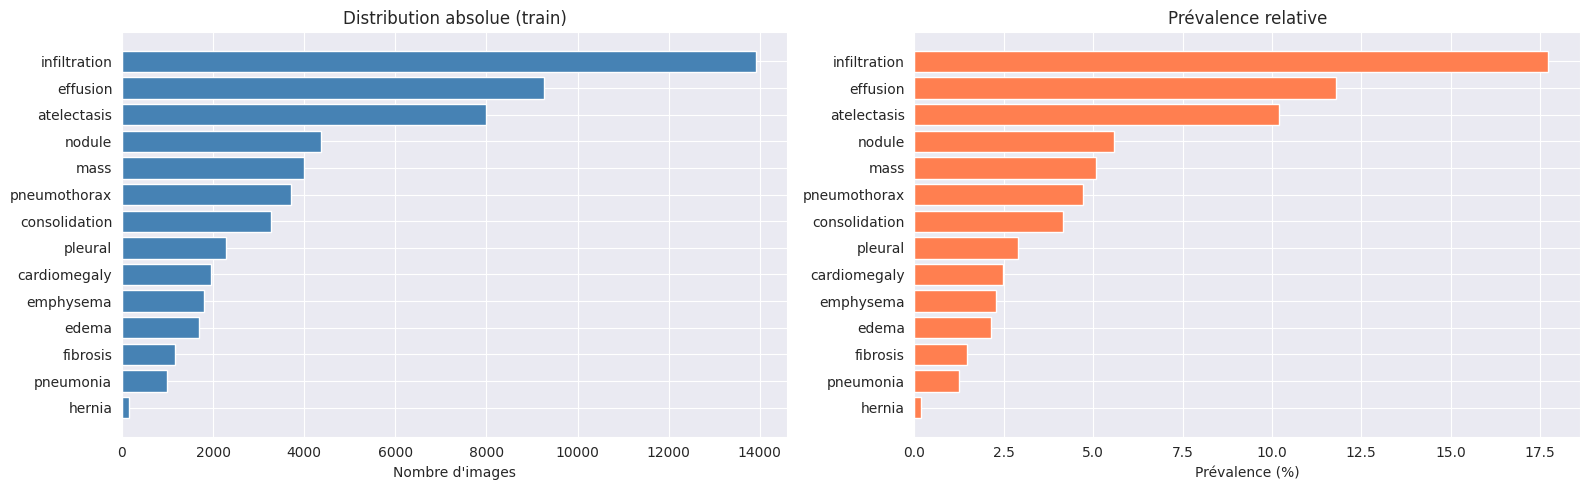

Images sans aucune pathologie: 54.04%


In [7]:
label_counts = y_train.sum(axis=0).astype(int)
label_df = pd.DataFrame({
    'class':      CLASS_NAMES,
    'count':      label_counts,
    'prevalence': label_counts / len(y_train)
}).sort_values('count', ascending=False)

print(label_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(label_df['class'], label_df['count'], color='steelblue')
axes[0].set_xlabel("Nombre d'images")
axes[0].set_title('Distribution absolue (train)')
axes[0].invert_yaxis()

axes[1].barh(label_df['class'], label_df['prevalence'] * 100, color='coral')
axes[1].set_xlabel('Prévalence (%)')
axes[1].set_title('Prévalence relative')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_class_distribution.png', dpi=120)
plt.show()

print(f"Images sans aucune pathologie: {(y_train.sum(axis=1) == 0).mean():.2%}")

## 3. Co-occurrences de pathologies

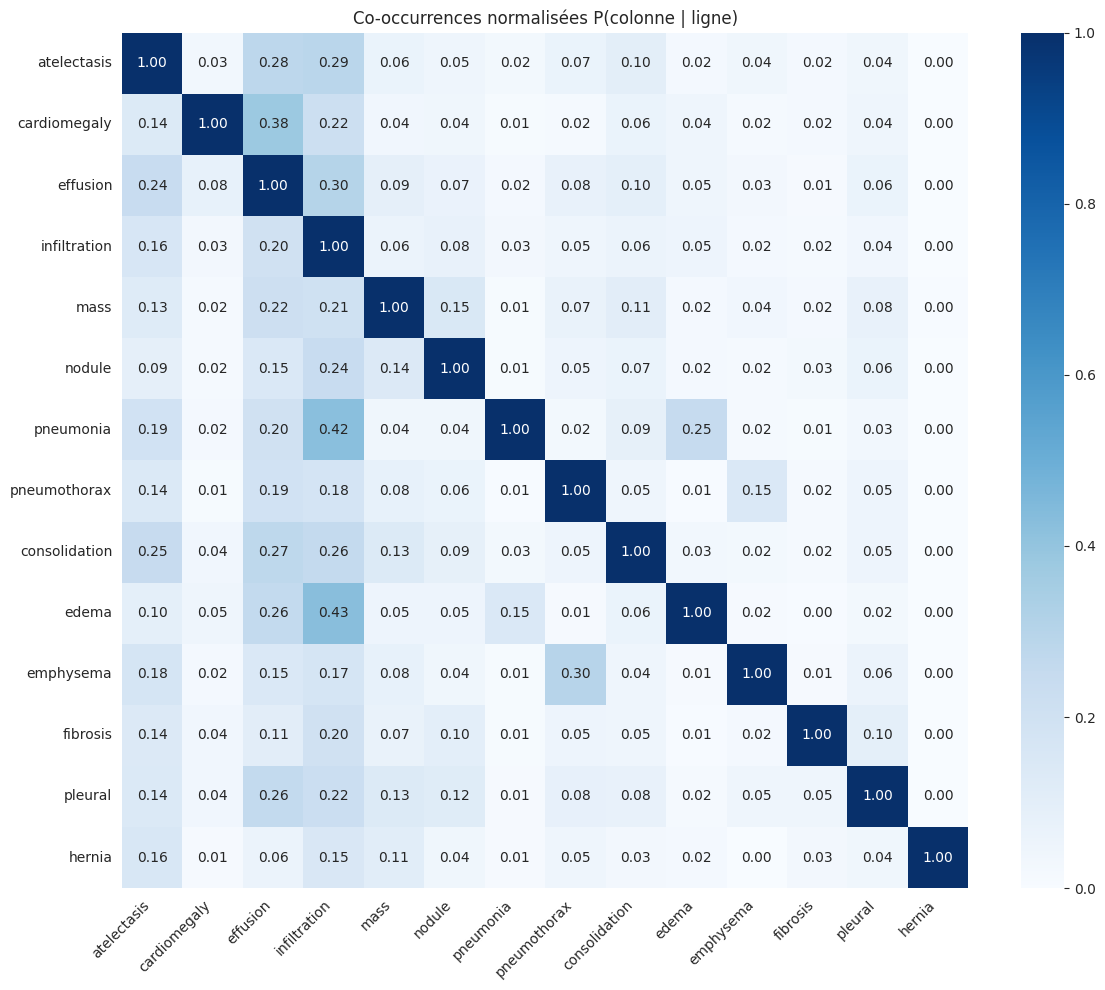

In [8]:
co_matrix     = (y_train.T @ y_train).astype(float)
diag          = np.diag(co_matrix)
co_normalized = co_matrix / (diag[:, None] + 1e-8)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(co_normalized, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot=True, fmt='.2f', cmap='Blues', ax=ax, vmin=0, vmax=1)
ax.set_title('Co-occurrences normalisées P(colonne | ligne)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_cooccurrence.png', dpi=120)
plt.show()

## 4. Exemples visuels par classe

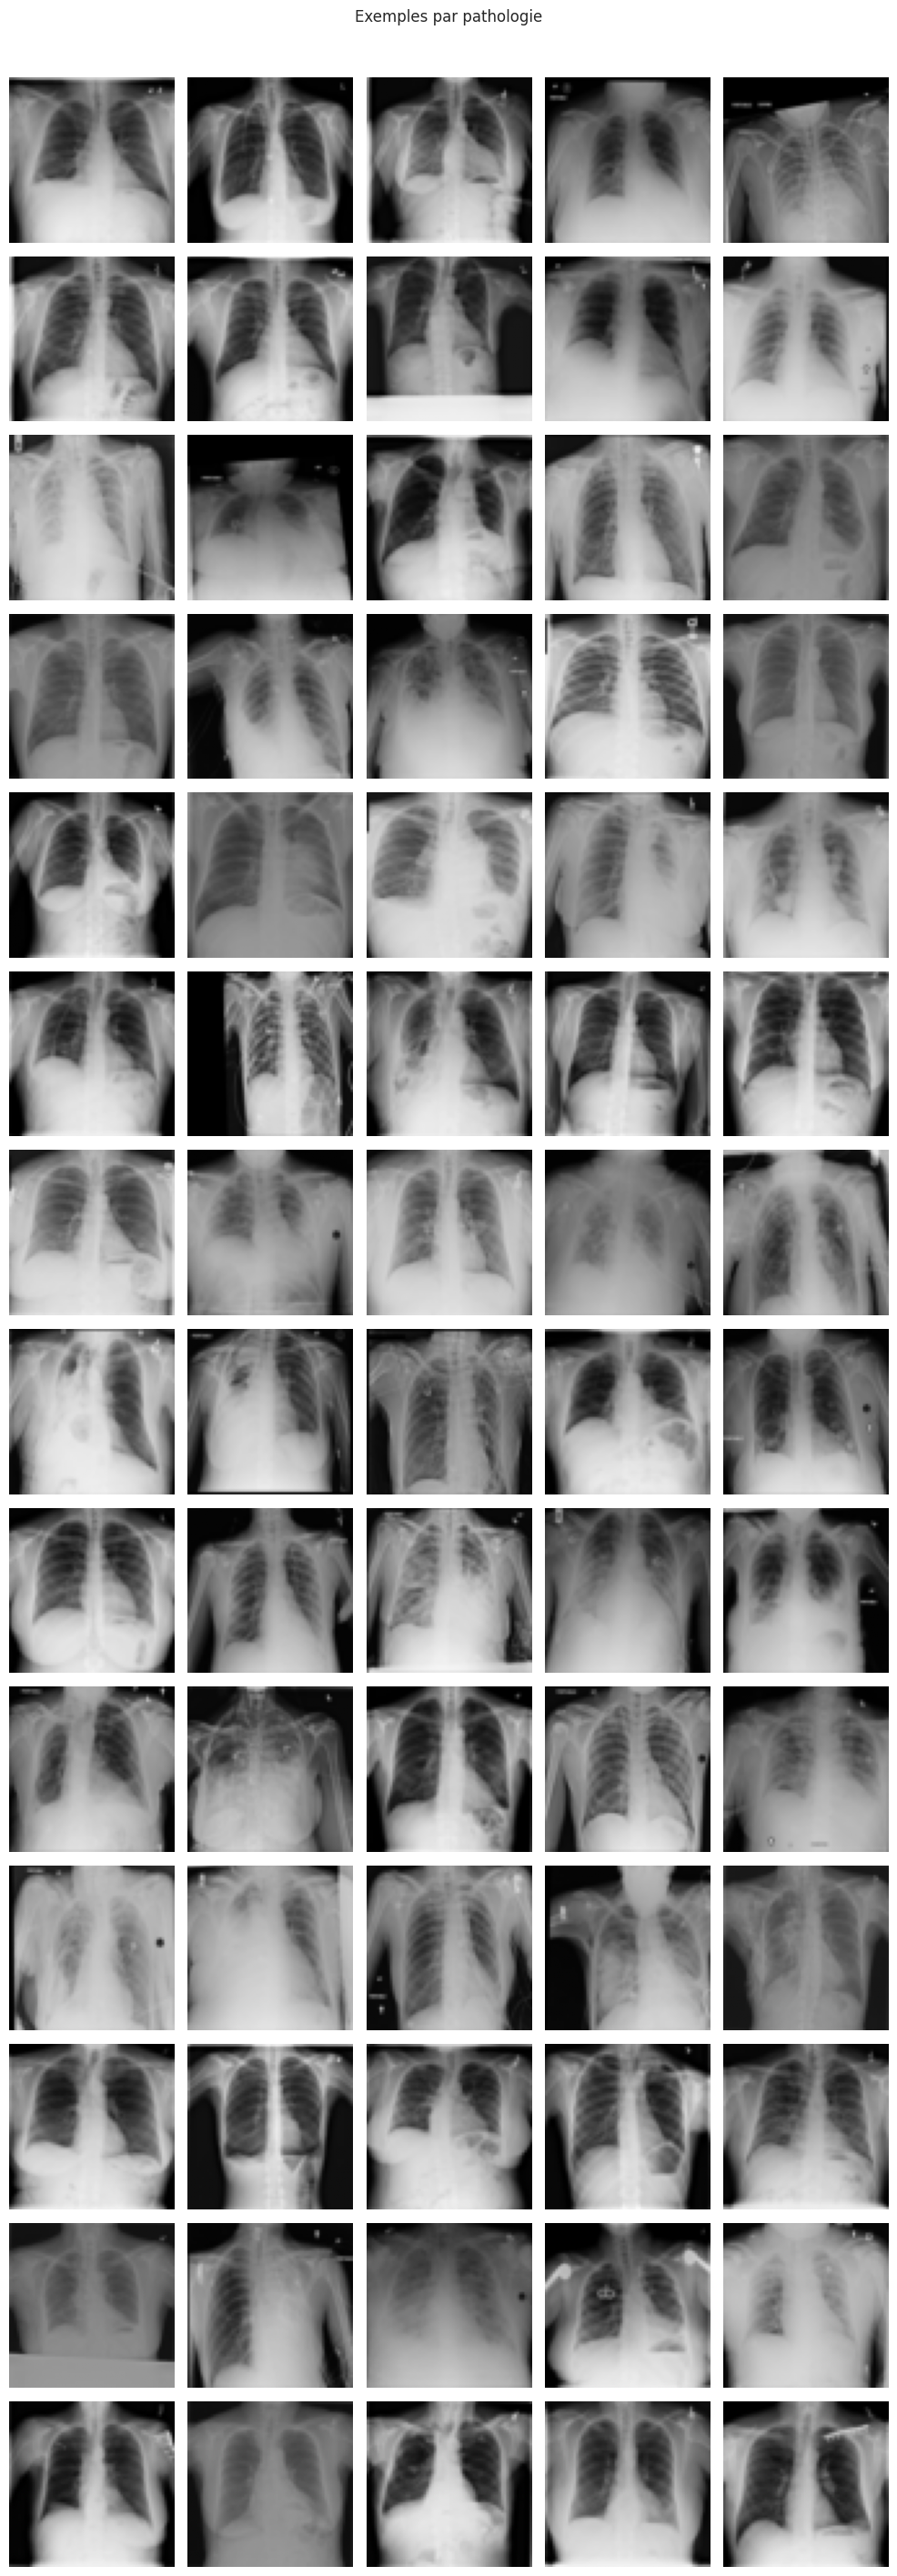

In [9]:
n_cols = 5
fig, axes = plt.subplots(N_CLASSES, n_cols, figsize=(n_cols * 2, N_CLASSES * 2))

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    pos_idx  = np.where(y_train[:, cls_idx] == 1)[0]
    sampled  = random.sample(pos_idx.tolist(), min(n_cols, len(pos_idx)))
    for col, idx in enumerate(sampled):
        axes[cls_idx, col].imshow(X_train[idx].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[cls_idx, col].axis('off')
        if col == 0:
            axes[cls_idx, col].set_ylabel(cls_name, fontsize=7)
    for col in range(len(sampled), n_cols):
        axes[cls_idx, col].axis('off')

plt.suptitle('Exemples par pathologie', y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_samples_per_class.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Normalisation et préparation des splits

In [10]:
import gc

DATA_DIR_STR = str(DATA_DIR)

# on traite split par split pour ne pas avoir les trois versions (original, norm, rgb) en RAM en meme temps

for split_name, X, y in [
    ("train", X_train, y_train),
    ("val",   X_val,   y_val),
    ("test",  X_test,  y_test),
]:
    # normalisation dans [-1, 1] pour le CNN scratch
    X_norm = X * 2.0 - 1.0
    np.save(DATA_DIR / f"X_{split_name}_norm.npy", X_norm)

    # version RGB a 3 canaux pour les backbones pre-entraines
    X_rgb = np.repeat(X, 3, axis=-1)
    np.save(DATA_DIR / f"X_{split_name}_rgb.npy", X_rgb)

    # on sauvegarde aussi les labels
    np.save(DATA_DIR / f"y_{split_name}.npy", y)

    print(f"{split_name}: norm {X_norm.shape} sauvegarde | rgb {X_rgb.shape} sauvegarde")

    del X_norm, X_rgb
    gc.collect()

# calcul des poids positifs pour la BCELoss ponderee, c'est le ratio neg/pos par classe
y_train_loaded = np.load(DATA_DIR / "y_train.npy")
pos_counts = y_train_loaded.sum(axis=0)
neg_counts  = len(y_train_loaded) - pos_counts
pos_weight  = neg_counts / (pos_counts + 1e-8)

del X_train, X_val, X_test, y_train_loaded
gc.collect()

print(f"pos_weight min={pos_weight.min():.1f} max={pos_weight.max():.1f}")

train: norm (78468, 64, 64, 1) sauvegarde | rgb (78468, 64, 64, 3) sauvegarde
val: norm (11219, 64, 64, 1) sauvegarde | rgb (11219, 64, 64, 3) sauvegarde
test: norm (22433, 64, 64, 1) sauvegarde | rgb (22433, 64, 64, 3) sauvegarde
pos_weight min=4.6 max=543.9


## 6. Pipeline tf.data avec augmentation Keras

In [11]:
# on verifie rapidement que le pipeline tf.data tourne bien a partir des fichiers sauvegardes sur disque
X_check = np.load(DATA_DIR / "X_train_norm.npy", mmap_mode="r")
y_check  = np.load(DATA_DIR / "y_train.npy")

AUTOTUNE = tf.data.AUTOTUNE

def build_dataset(X, y, shuffle=False, augment=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((X[:1000].astype(np.float32),
                                              y[:1000].astype(np.float32)))
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

ds_check = build_dataset(X_check, y_check, shuffle=True)
for bx, by in ds_check.take(1):
    print(f"Batch gray — images: {bx.shape} | labels: {by.shape}")

del X_check, y_check, ds_check
import gc; gc.collect()
print("Pipeline tf.data valide")

I0000 00:00:1774893560.754280    1596 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5578 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Batch gray — images: (64, 64, 64, 1) | labels: (64, 14)


2026-03-30 19:59:31.722929: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Pipeline tf.data valide


## 7. Sauvegarde de la configuration

In [12]:
config = {
    "seed":        SEED,
    "img_size":    IMG_SIZE,
    "batch_size":  BATCH_SIZE,
    "n_classes":   N_CLASSES,
    "class_names": CLASS_NAMES,
    "pos_weight":  pos_weight.tolist(),
    "data_dir":    str(DATA_DIR)
}
with open(DATA_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Configuration sauvegardee dans", DATA_DIR / "config.json")
import os
saved_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".npy") or f.endswith(".json")]
print("Fichiers sauvegardes:", sorted(saved_files))

Configuration sauvegardee dans ../Aide-au-tri-radiologique-/data/variable_data/config.json
Fichiers sauvegardes: ['X_test_norm.npy', 'X_test_rgb.npy', 'X_train_norm.npy', 'X_train_rgb.npy', 'X_val_norm.npy', 'X_val_rgb.npy', 'config.json', 'y_test.npy', 'y_train.npy', 'y_val.npy']
